In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sql_functions import read_query

In [ ]:
#import sys
#!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [8]:
query ="select * from customers limit 5"ArithmeticErrorread_query(query)

SyntaxError: invalid syntax (2898013205.py, line 1)

In [9]:
query ="select * from customers limit 5"
read_query(query)

,CustomerID,FirstName,LastName,Email,Phone,Address,State
0,C-2023-100-1,Mahika,Sunder,MahikaSunder_11@zmail.com,03412176590,"H.No. 155, Chana",Assam
1,C-2023-100-10,Zeeshan,Vasa,ZeeshanVasa_1@zmail.com,+911151051656,"52, Roy Nagar",Tripura
2,C-2023-100-100,Aaina,Sachdeva,AainaSachdeva_9@zmail.com,+918834507719,"75/92, Kade Marg",Nagaland
3,C-2023-100-101,Shray,Bajwa,ShrayBajwa_11@zmail.com,07410498662,"45, Bora Ganj",Manipur
4,C-2023-100-102,Navya,Dash,NavyaDash_5@zmail.com,+917644200850,70/782\nBahl Road,Kerala


In [11]:
query="select * from salesdata limit 5"
read_query(query)

,SaleID,CustomerID,SubcatID,EmployeeID,SaleDate,Quantity,TotalPrice
0,23000,C-2023-100-12,6002,1100,2023-05-02,2,176432.00
1,23001,C-2023-100-141,6029,1115,2023-12-26,2,47172.00
2,23002,C-2023-100-86,6029,1035,2023-03-26,2,47172.00
3,23003,C-2023-100-72,6006,1016,2023-08-01,2,117644.00
4,23004,C-2023-100-142,6030,1067,2023-03-06,5,336560.00


In [27]:
query = '''select t.customerid, c.firstname, t.expenditure
from
(select sd.customerid, sb.subcatname, 
sum(sd.totalprice) as expenditure
from salesdata as sd
join subcategories sb on
sd.subcatid = sb.subcatid
group by sb.subcatname, sd.customerid
order  by expenditure desc
limit 10)  t

join customers as  c on
c.customerid = t.customerid ''' 


total_expenditure = read_query(query)

In [32]:
customer = total_expenditure ["firstname"].values

In [33]:
expend = total_expenditure["expenditure"].astype(float)

<BarContainer object of 10 artists>

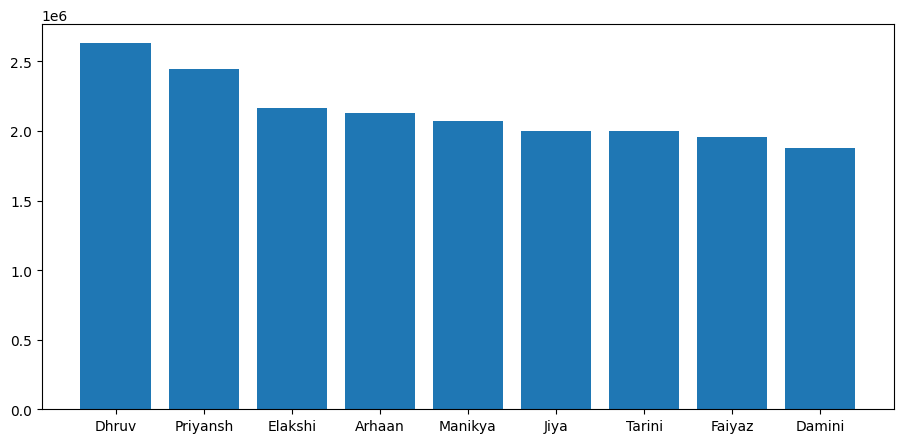

In [36]:
plt.figure(figsize=(11,5))
plt.bar(x = customer, height = expend)